# Lecture 5. Topic Models

Natural Language Processing for Law and Social Science<br>
Elliott Ash, ETH Zurich

In [24]:
# set random seed
import numpy as np
np.random.seed(4)
import seaborn as sns
sns.set_theme()

In [25]:
# Setup
import warnings; warnings.simplefilter('ignore')
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')

In [26]:
from gensim.utils import simple_preprocess
text0 = ' '.join(simple_preprocess(df['opinion_text'][0]))
text1 = ' '.join(simple_preprocess(df['opinion_text'][1]))

text1[:1000]

'justice stevens delivered the opinion of the court in most of the united states not including california the minimum price paid to dairy farmers producing raw milk is regulated pursuant to federal marketing orders those orders guarantee uniform price for the producers but through pooling mechanisms require the processors of different classes of dairy products to pay different prices thus for example processors of fluid milk pay premium price part of which goes into an equalization pool that provides partial subsidy for cheese manufacturers who pay net price that is lower than the farmers receive seewest lynn creamery inc healy ed ct the california legislature has adopted similar program to regulate the minimum prices paid by california processors to california producers in the cases before us today out of state producers are challenging the of amendment to that program they present us with two questions whether of the federal agriculture improvement and reform act of stat usc uscs exe

In [27]:
from gensim.utils import simple_preprocess
df['preprocessed'] = df['opinion_text'].apply(lambda x: ' '.join(simple_preprocess(x)))

from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=500,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['preprocessed'])
words = vectorizer.get_feature_names_out()

In [28]:
X = X.todense()
X = X / X.sum(axis=1)
features = []
for i, word in enumerate(words):
    column = X[:,i]
    df['x_'+word] = np.ravel(column)
    features.append('x_'+word)
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,...,x_violation,x_water,x_way,x_west,x_word,x_words,x_work,x_year,x_years,x_york
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...,...,0.003509,0.000000,0.001754,0.000000,0.000000,0.012281,0.000000,0.017544,0.000000,0.0
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...,...,0.000000,0.000000,0.000000,0.005263,0.000000,0.002632,0.000000,0.000000,0.000000,0.0
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...,...,0.001653,0.000000,0.001653,0.000000,0.000000,0.000000,0.000000,0.013223,0.001653,0.0
4,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...,...,0.000000,0.013601,0.002863,0.000000,0.000716,0.000000,0.000000,0.000716,0.002863,0.0
5,"REGINALD A. WILKINSON, DIRECTOR, OHIO DEPARTME...",majority,2005-06-13,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],4.0,4230.0,Justice Kennedy delivered the opinion of the C...,...,0.001903,0.000000,0.000000,0.000000,0.000951,0.000000,0.000951,0.002854,0.000951,0.0


## Principal Component Analysis

How it works (more info [here](https://towardsdatascience.com/principal-component-analysis-for-dimensionality-reduction-115a3d157bad)):

1. Construct the covariance matrix of the standardized features
2. Get the eigenvectors and eigenvalues
3. Select k eigenvectors which correspond to the k largest eigenvalues, where k is the dimensionality of the new feature subspace (the number of principal components)
4. Construct the projection matrix from these k eigenvectors and transform the features using this matrix

In [29]:
#%% Principal Components
y = (df['log_cite_count']>df.log_cite_count.mean()).astype('int')
X = df[features]

from sklearn.decomposition import PCA
pca = PCA(n_components=3,svd_solver='randomized')
Xpca = pca.fit_transform(X)
pca.explained_variance_ratio_

array([0.04926308, 0.04705151, 0.04333349])

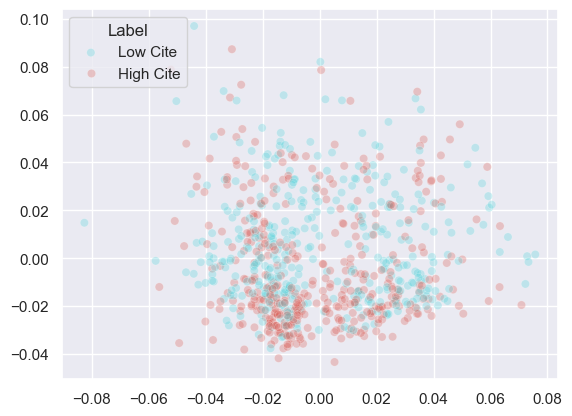

In [30]:
plot = sns.scatterplot(
    x=Xpca[:,0], y=Xpca[:,1],
    hue=y,
    palette=sns.color_palette("hls", 2),
    legend="full",
    alpha=0.3
)

plt.legend(title='Label', loc='upper left', labels=["Low Cite", "High Cite"])
plt.show(plot)

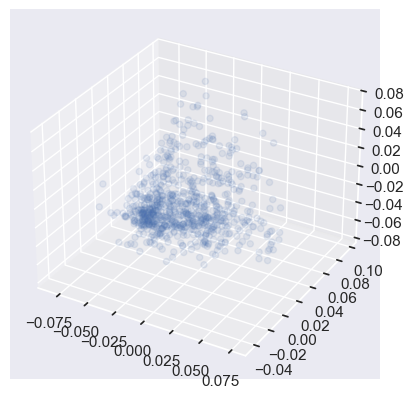

In [31]:
#%% PCA 3D Viz
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Xpca[:,0], Xpca[:,1], Xpca[:,2], alpha=.1)
plt.show()

In [32]:
#%% make components to explain 95% of variance
X = df[features]
pca = PCA(n_components=.95, svd_solver='full')
X95 = pca.fit_transform(X)
pca.n_components_

np.int64(232)

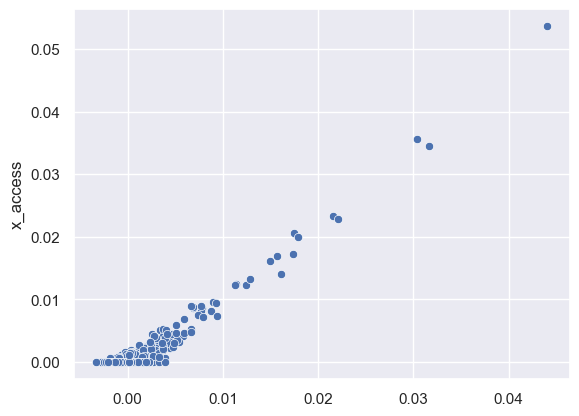

In [33]:
#%% PCA Inverse Transform
Xrestore = pca.inverse_transform(X95)
plot = sns.scatterplot(x=Xrestore[:,0],y=X.iloc[:, 0])

In [34]:
#%% Incremental PCA
X_mm = np.memmap('X.pkl',shape=(32567, 525))

from sklearn.decomposition import IncrementalPCA
inc_pca = IncrementalPCA(n_components=100, batch_size=1000)
inc_pca.fit(X_mm)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",100
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",1000


In [35]:
#%% PC Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
Y = df['log_cite_count']
lin_reg = LinearRegression()
scores = cross_val_score(lin_reg,
                         X95[:,:10],
                         Y) 
scores.mean()

np.float64(0.15324540528832625)

#### [MDS](https://towardsdatascience.com/mds-multidimensional-scaling-smart-way-to-reduce-dimensionality-in-python-7c126984e60b), [Isomap](https://towardsdatascience.com/isomap-embedding-an-awesome-approach-to-non-linear-dimensionality-reduction-fc7efbca47a0), [T-SNE](https://towardsdatascience.com/an-introduction-to-t-sne-with-python-example-5a3a293108d1)


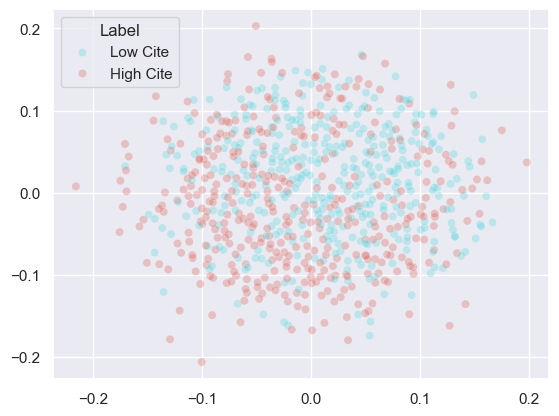

In [36]:
#%% MDS, Isomap, and T-SNE
from sklearn.manifold import MDS, Isomap, TSNE
mds = MDS(n_components=2)
Xmds = mds.fit_transform(X)
plot = sns.scatterplot(
    x=Xmds[:,0], y=Xmds[:,1],
    hue=y,
    palette=sns.color_palette("hls", 2),
    legend="full",
    alpha=0.3
)

plt.legend(title='Label', loc='upper left', labels=["Low Cite", "High Cite"])
plt.show(plot)

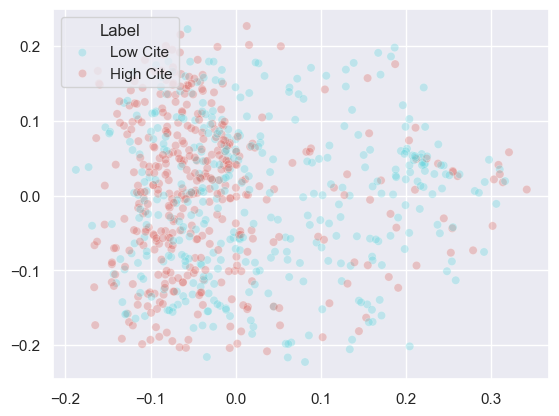

In [37]:
#%% Isomap
iso = Isomap(n_components=2)
Xiso = iso.fit_transform(X)
plot = sns.scatterplot(
    x=Xiso[:,0], y=Xiso[:,1],
    hue=y,
    palette=sns.color_palette("hls", 2),
    legend="full",
    alpha=0.3
)

plt.legend(title='Label', loc='upper left', labels=["Low Cite", "High Cite"])
plt.show(plot)

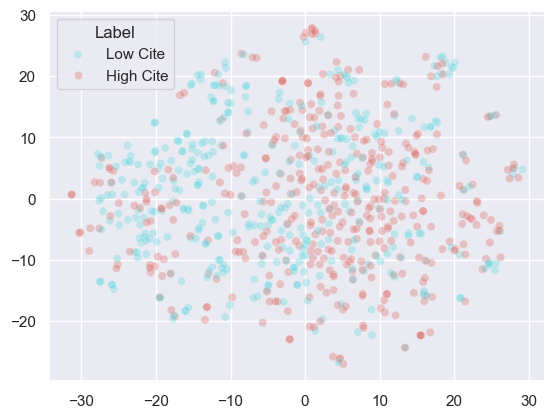

In [39]:
#%% t-SNE
tsne = TSNE(n_components=2, max_iter=500, perplexity=25)
Xtsne = tsne.fit_transform(X)
plot = sns.scatterplot(
    x=Xtsne[:,0], y=Xtsne[:,1],
    hue=y,
    palette=sns.color_palette("hls", 2),
    legend="full",
    alpha=0.3
)

plt.legend(title='Label', loc='upper left', labels=["Low Cite", "High Cite"])
plt.show(plot)

# Latent Dirichlet Allocation

For further reference see the material from topic [modeling with gensim](https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/).

In [40]:
# clean document
from gensim.utils import simple_preprocess
import spacy
from spacy.tokenizer import Tokenizer
from tqdm import tqdm as tq
nlp = spacy.load('en_core_web_sm')
# this is faster and we don't need the whole grammatical parse analysis

def tokenize(x, nlp):
    # lemmatize and lowercase without stopwords, punctuation and numbers
    return [w.lemma_.lower() for w in nlp(x) if not w.is_stop and not w.is_punct and not w.is_digit and len(w) > 2]

# split into paragraphs
doc_clean = []
for doc in tq(df['opinion_text'][:100]):
    # split by paragraph
    for paragraph in doc.split("\n\n"):
        doc_clean.append(tokenize(paragraph, nlp))

# randomize document order
from random import shuffle
shuffle(doc_clean)

# creating the term dictionary
from gensim import corpora
dictionary = corpora.Dictionary(doc_clean)
# filter extremes, drop all words appearing in less than 10 paragraphs and all words appearing in at least every third paragraph
dictionary.filter_extremes(no_below=10, no_above=0.33, keep_n=1000)
print (len(dictionary))

100%|██████████| 100/100 [02:55<00:00,  1.76s/it]


1000


In [41]:
# creating the document-term matrix
doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]

# train LDA with 10 topics and print
from gensim.models.ldamodel import LdaModel
lda = LdaModel(doc_term_matrix, num_topics=10, 
               id2word = dictionary, passes=3)
lda.show_topics(formatted=False)

[(0,
  [('u.s.', np.float32(0.03585542)),
   ('right', np.float32(0.020338275)),
   ('state', np.float32(0.017328957)),
   ('amendment', np.float32(0.013899246)),
   ('law', np.float32(0.013339323)),
   ('clause', np.float32(0.013278989)),
   ('congress', np.float32(0.01241396)),
   ('process', np.float32(0.011108671)),
   ('federal', np.float32(0.00946423)),
   ('government', np.float32(0.009260538))]),
 (1,
  [('states', np.float32(0.024508713)),
   ('u.s.', np.float32(0.022872189)),
   ('united', np.float32(0.021891264)),
   ('law', np.float32(0.017857768)),
   ('congress', np.float32(0.01232463)),
   ('foreign', np.float32(0.011941197)),
   ('state', np.float32(0.011643041)),
   ('act', np.float32(0.011561547)),
   ('f.3d', np.float32(0.011505979)),
   ('use', np.float32(0.010395136))]),
 (2,
  [('claim', np.float32(0.040534917)),
   ('state', np.float32(0.034381118)),
   ('federal', np.float32(0.02177755)),
   ('respondent', np.float32(0.017473064)),
   ('justice', np.float32(0.01

In [42]:
# to get the topic proportions for a document, use
# the corresponding row from the document-term matrix.
lda[doc_term_matrix[1]]

[(2, np.float32(0.12320562)),
 (3, np.float32(0.617571)),
 (4, np.float32(0.07903611)),
 (5, np.float32(0.037292164)),
 (7, np.float32(0.13482739))]

In [43]:
# or, for all documents
[lda[d] for d in doc_term_matrix]

[[(0, np.float32(0.40334135)),
  (3, np.float32(0.11132707)),
  (9, np.float32(0.44847295))],
 [(2, np.float32(0.12325959)),
  (3, np.float32(0.6175711)),
  (4, np.float32(0.079055)),
  (5, np.float32(0.03728984)),
  (7, np.float32(0.13475674))],
 [(3, np.float32(0.6034933)),
  (5, np.float32(0.23108241)),
  (7, np.float32(0.14791985))],
 [(0, np.float32(0.31781706)),
  (1, np.float32(0.27688017)),
  (2, np.float32(0.38637534))],
 [(0, np.float32(0.025001924)),
  (1, np.float32(0.02500076)),
  (2, np.float32(0.7749874)),
  (3, np.float32(0.025004253)),
  (4, np.float32(0.025000518)),
  (5, np.float32(0.025000673)),
  (6, np.float32(0.025001068)),
  (7, np.float32(0.025001371)),
  (8, np.float32(0.025000589)),
  (9, np.float32(0.025001546))],
 [(0, np.float32(0.35723987)),
  (4, np.float32(0.46764395)),
  (9, np.float32(0.15803733))],
 [(0, np.float32(0.4035735)), (4, np.float32(0.55641323))],
 [(0, np.float32(0.011111678)),
  (1, np.float32(0.0111114895)),
  (2, np.float32(0.0111127)),

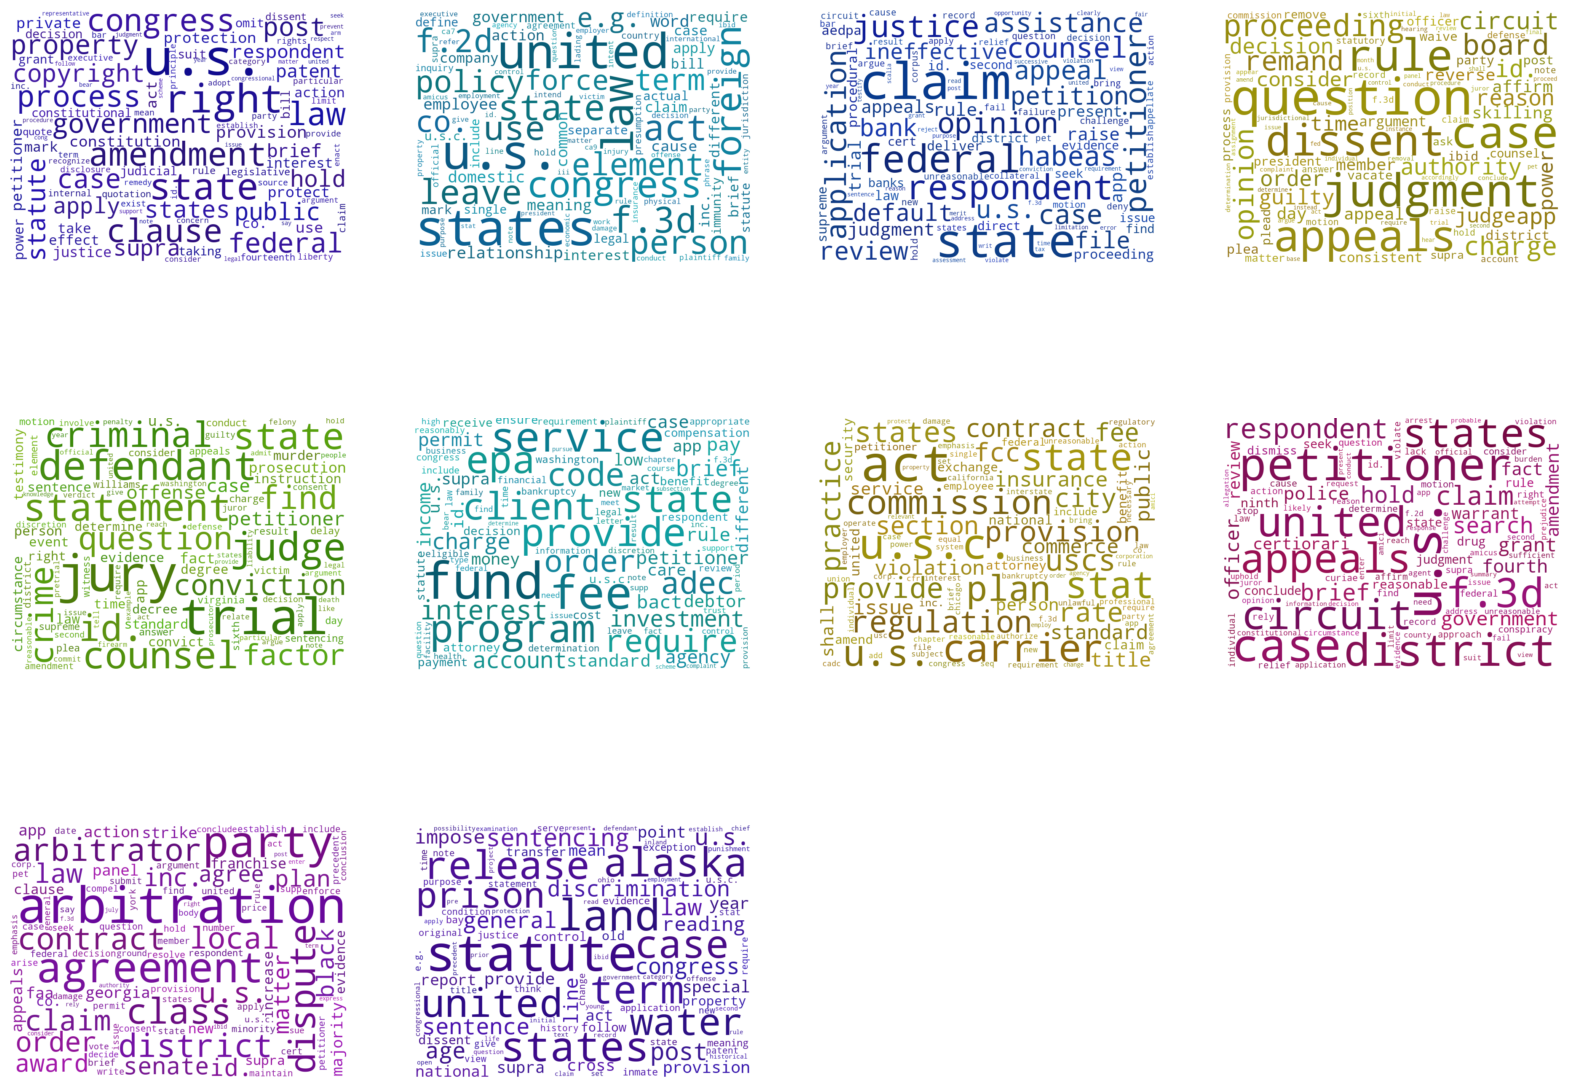

In [44]:
###
# LDA Word Clouds
###

from numpy.random import randint
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = [20, 15]
# make word clouds for the topics
for i,weights in lda.show_topics(num_topics=-1,
                                 num_words=100,
                                 formatted=False):
    
    #logweights = [w[0], np.log(w[1]) for w in weights]
    maincol = randint(0,360)
    def colorfunc(word=None, font_size=None, 
                  position=None, orientation=None, 
                  font_path=None, random_state=None):   
        color = randint(maincol-10, maincol+10)
        if color < 0:
            color = 360 + color
        return "hsl(%d, %d%%, %d%%)" % (color,randint(65, 75)+font_size / 7, randint(35, 45)-font_size / 10)   

    
    wordcloud = WordCloud(background_color="white", 
                          ranks_only=False, 
                          max_font_size=120,
                          color_func=colorfunc,
                          height=600,width=800).generate_from_frequencies(dict(weights))

    plt.subplot(3, 4, i+1)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    

In [45]:
# pyLDAvis, for more details, refer to https://github.com/bmabey/pyLDAvis
#!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
pyLDAvis.enable_notebook()
gensimvis.prepare(lda, doc_term_matrix, dictionary)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.060794 -0.012747       1        1  16.053189
1      0.128430 -0.056741       2        1  13.059864
4     -0.114879 -0.138326       3        1  10.548180
2     -0.139535  0.025334       4        1  10.534397
7     -0.078548  0.021150       5        1   9.630108
9      0.056107 -0.082094       6        1   9.204404
6      0.136991  0.050974       7        1   8.732631
5      0.073021 -0.020252       8        1   8.453534
8      0.018764  0.165664       9        1   6.934081
3     -0.141143  0.047037      10        1   6.849613, topic_info=            Term         Freq        Total Category  logprob  loglift
437  arbitration   497.000000   497.000000  Default  30.0000  30.0000
783         jury   495.000000   495.000000  Default  29.0000  29.0000
27         claim  1476.000000  1476.000000  Default  28.0000  28.0000
287        trial   664.000000   664.000000  Default  27.0000  27.0000
254    agreement   475.000000   475.000000  Default  26.0000  26.0000
..           ...          ...          ...      ...      ...      ...
260     decision    86.832357   615.625612  Topic10  -4.8793   0.7223
201        judge    80.460548   432.771234  Topic10  -4.9555   0.9985
288     consider    80.526215   451.787493  Topic10  -4.9547   0.9563
82          time    78.593485   478.799782  Topic10  -4.9789   0.8740
447     argument    75.803306   409.472497  Topic10  -5.0151   0.9943

[551 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
18        1  0.032826  account
18        3  0.070342  account
18        4  0.075032  account
18        5  0.028137  account
18        6  0.032826  account
...     ...       ...      ...
754       3  0.060903     york
754       7  0.389779     york
754       9  0.438501     york
372       3  0.233884    young
372       6  0.735064    young

[2757 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 5, 3, 8, 10, 7, 6, 9, 4])

Using Mallet to calculate coherence scores for different number of topics to automatically determine the best number of topics. Alternatively, you can use LdaMulticore.

In [47]:
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel

scores = []
for num_topics in range(2, 20, 2):
    print(num_topics)
    lda = LdaMulticore(doc_term_matrix, num_topics=num_topics, id2word=dictionary, passes=3, workers=2)
    coherence = CoherenceModel(model=lda, texts=doc_clean, corpus=doc_term_matrix, dictionary=dictionary, coherence='c_v')
    scores.append((num_topics, coherence.get_coherence()))

pd.DataFrame(scores, columns=["Number of Topics", "Coherence Scores"])

2
4
6
8
10
12
14
16
18


,Number of Topics,Coherence Scores
0,2,0.348342
1,4,0.327467
2,6,0.330206
3,8,0.310439
4,10,0.319554
5,12,0.337178
6,14,0.325465
7,16,0.323793
8,18,0.297506


## Singular Value Decomposition (SVD)

For further reference for this and the following section see [here](https://github.com/fastai/course-nlp/blob/219d0c217bd83339e21471d31cd787e86d6ec0a0/2-svd-nmf-topic-modeling.ipynb).

In [ ]:
from scipy import linalg

X = np.asarray(pd.read_pickle('X.pkl').todense())
vec = pd.read_pickle('vec-3grams-1.pkl')
vocab = np.array(vec.get_feature_names_out())
vocab[400:500]

In [50]:
U, s, Vh = linalg.svd(X, full_matrices=False)
print(U.shape, s.shape, Vh.shape)

(768, 768) (768,) (768, 1000)


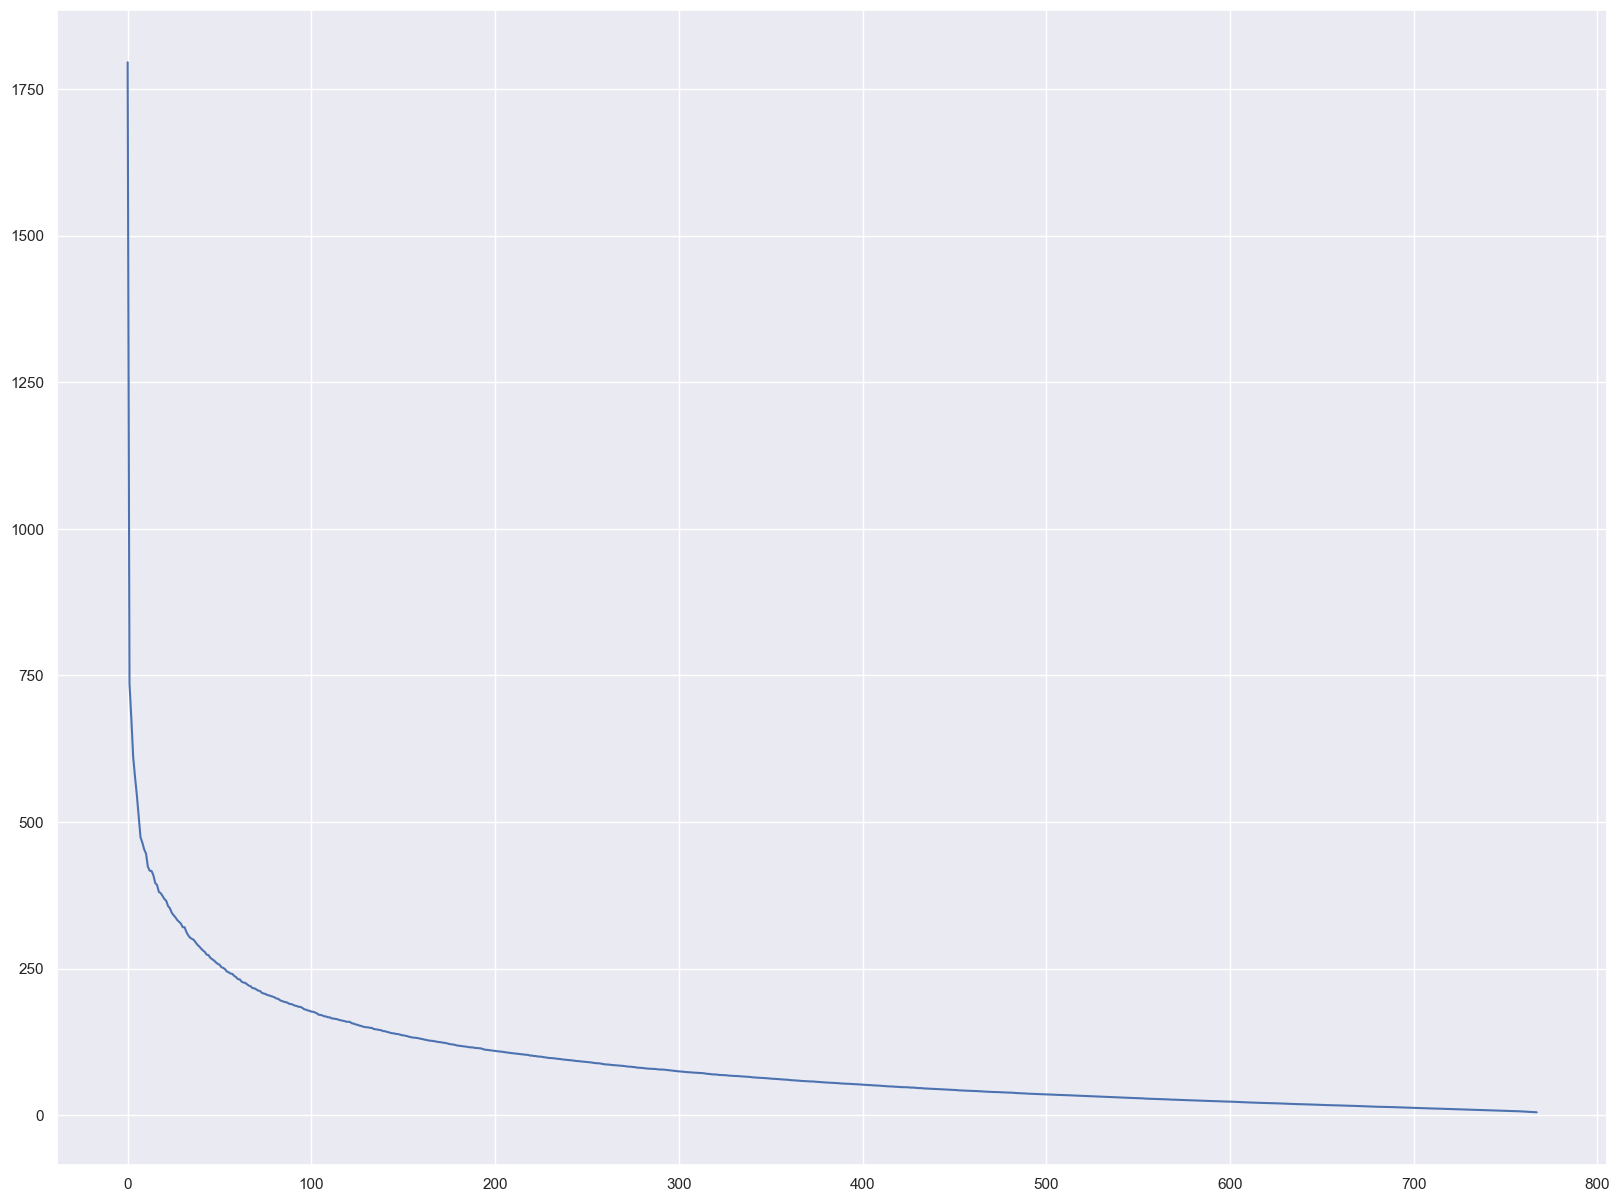

In [51]:
plt.plot(s)

In [52]:
num_top_words=8

def show_topics(a):
    top_words = lambda t: [vocab[i] for i in np.argsort(t)[:-num_top_words-1:-1]]
    topic_words = ([top_words(t) for t in a])
    return [' '.join(t) for t in topic_words]

show_topics(Vh[:10])

['state act district congress rule statute government courts',
 'act congress government action statute agency jurisdiction commission',
 'trial defendant rule evidence judge jury government sentence',
 'amendment right congress bear government use statute rights',
 'act congress state jurisdiction statute commission authority agency',
 'plan school death district jury districts minority penalty',
 'district military war congress death habeas commission sentence',
 'school government public tax religious schools program commission',
 'commission tax rate party military judge war plan',
 'counsel rate service evidence right cost act epa']

## Non-negative Matrix Factorization (NMF) 

In [ ]:
from sklearn import decomposition

clf = decomposition.NMF(n_components=10, random_state=1)

W1 = clf.fit_transform(np.asarray(X))
H1 = clf.components_

show_topics(H1)

## Author Topic Model

In [56]:
from gensim.models import AuthorTopicModel
from gensim.test.utils import temporary_file

df = df.reset_index()
df['id'] = df.index
author2doc = df[:100][['authorship','id']]
author2doc = author2doc.groupby('authorship').apply(lambda x: list(x['id'])).to_dict()
author2doc

{'ALITO': [14, 29, 30, 33, 39, 43],
 'BREYER': [6, 10, 15, 19, 26, 36, 54, 73, 74, 80, 81, 95],
 'GINSBURG': [0, 7, 9, 11, 18, 25, 27, 52, 68, 84, 86, 90, 96, 97],
 'KENNEDY': [3, 4, 16, 21, 34, 40, 42, 48, 62, 64, 65, 76, 85, 87],
 "O'CONNOR": [2, 49, 59, 66, 75, 83, 88],
 'REHNQUIST': [55, 56, 70, 79, 94],
 'ROBERTS': [12, 35, 44],
 'SCALIA': [20, 23, 28, 37, 41, 45, 51, 61, 63, 82, 98],
 'SOUTER': [5, 47, 53, 67, 72, 78, 91, 92],
 'STEVENS': [1, 17, 31, 32, 38, 46, 57, 60, 71, 93],
 'THOMAS': [8, 13, 22, 24, 50, 58, 69, 77, 89, 99]}

In [ ]:
model = AuthorTopicModel(
        doc_term_matrix, author2doc=author2doc, id2word=dictionary, num_topics=10)

# For each author list topic distribution
author_vecs = [model.get_author_topics(author) for author in model.id2author.values()]
author_vecs[:2]

[[(0, np.float64(0.10440041455512315)),
  (1, np.float64(0.020550979129625432)),
  (2, np.float64(0.3514377084122073)),
  (3, np.float64(0.0890557683919657)),
  (4, np.float64(0.1578806363620077)),
  (5, np.float64(0.14455473692453674)),
  (6, np.float64(0.02560100082776115)),
  (7, np.float64(0.04076350586173177)),
  (8, np.float64(0.06452257428477896))],
 [(1, np.float64(0.07144336214251482)),
  (8, np.float64(0.04003082923308235)),
  (9, np.float64(0.8861198059496926))]]

: 